#**1. 벡터 데이터베이스**
벡터 데이터베이스(Vector Database)는 텍스트, 이미지, 오디오와 같은 데이터를 고차원 벡터 형태로 변환해 저장하고, 이 벡터 간의 유사도를 빠르게 검색할 수 있도록 최적화된 데이터베이스입니다. 일반적인 관계형 데이터베이스가 정확한 값 기반 검색(SQL 쿼리 등)에 적합하다면, 벡터 데이터베이스는 의미적 유사성(semantic similarity)에 기반한 검색을 지원하여 예를 들어 "강아지"와 "개"처럼 다른 표현이라도 비슷한 의미의 데이터를 찾아낼 수 있습니다. 이를 위해 코사인 유사도, 내적(dot product), 유클리드 거리와 같은 수학적 거리 계산을 활용하며, 대규모 임베딩(embedding) 데이터를 효율적으로 관리하고 검색할 수 있어 추천 시스템, 검색 엔진, 생성형 AI의 RAG(Retrieval-Augmented Generation) 등에 널리 활용됩니다.

###**크로마디비**
크로마디비(ChromaDB)는 대표적인 오픈소스 벡터 데이터베이스로, 문서·이미지·코드 등 다양한 데이터를 임베딩 벡터로 변환해 저장하고, 이를 빠르게 검색할 수 있도록 설계된 시스템입니다. 파이썬 기반으로 사용이 간편하며, LangChain 같은 LLM 프레임워크와 잘 통합되어 RAG(Retrieval-Augmented Generation) 구조를 쉽게 구축할 수 있습니다. 내부적으로는 벡터 인덱싱과 메타데이터 저장을 함께 지원하여, 단순히 유사도 검색뿐 아니라 조건 필터링과 결합된 검색도 가능합니다. 무료로 가볍게 실행할 수 있고, 로컬 환경부터 클라우드까지 유연하게 확장할 수 있어 학습용이나 실무용 AI 검색 엔진 구축에 많이 활용됩니다.

In [1]:
import getpass
import os

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

OPENAI_API_KEY: ··········


In [2]:
!pip install langchain_community langchain_experimental langchain_openai pypdf

#**2. 청크**
청크(Chunk)는 긴 텍스트나 문서를 작은 단위로 나눈 조각을 의미하며, 주로 자연어 처리와 RAG(Retrieval-Augmented Generation) 같은 작업에서 사용됩니다. 대형 언어모델은 한 번에 처리할 수 있는 토큰 수에 한계가 있기 때문에 문서를 일정한 길이로 분할하여 임베딩 벡터로 변환하고, 이후 검색이나 질의 응답 시 필요한 청크만 불러와 모델에 전달하는 방식으로 효율성과 정확성을 높입니다. 청크는 단순히 일정 글자 수나 토큰 수로 나누기도 하지만, 문단·문장 단위 등 의미 단위로 나누어야 검색 품질이 좋아지며, 결국 청크는 방대한 데이터를 모델이 다룰 수 있는 크기로 잘게 나눈 최소 단위라고 할 수 있습니다.

#**SemanticChunker**
SemanticChunker는 텍스트를 단순히 일정한 길이로 자르는 방식이 아니라, 문장의 의미적 맥락을 고려해 자연스럽게 분할하는 청크 생성 기법입니다. 즉, 문장이나 문단의 의미가 단절되지 않도록 문맥 단위로 텍스트를 나누어 임베딩과 검색의 정확도를 높여줍니다. 이를 통해 RAG(Retrieval-Augmented Generation) 구조에서 모델이 보다 관련성 높은 정보를 검색할 수 있으며, 불필요하게 잘려나간 조각이나 중복된 정보 전달을 줄일 수 있습니다. 따라서 SemanticChunker는 의미 기반 검색과 대규모 문서 처리에서 효율성과 정밀도를 동시에 향상시키는 중요한 도구로 활용됩니다.

In [3]:
!pip install -qU langchain langchain-community langchain-openai
!pip install -qU langchain-text-splitters langchain-chroma chromadb
!pip install -qU rank_bm25 langchain-classic langgraph pypdf
!pip install -qU langchain-experimental

### 1. 일반 Chunking
- 1000자씩 자르기(문단 무시하고 자름)
- 문장이 중간에 잘림(의미가 깨짐)

### 2. SemantiChunker
- 문장 단위로 나눈 뒤
- 문장 간 의미 유사도를 계산(임베딩으로 변환)
- 의미가 바뀌는 지점에서 chunk를 나눔

### 단점
- 속도가 느림(임베딩, 유사도 계산)
- 비용 증가(임베딩 호출 횟수, OpenAI embedding을 사용하면)
- chunk 크기 불균형
- 완벽하지 않음(판단이 항상 정확하지 않음, 애매한 문장은 잘못 묶일 수 있음)
- 튜닝 난이도 있음(threshold, 잘못 설정하면 너무 잘게 쪼개지거나 너무 크게 묶임)

In [4]:
from langchain_community.document_loaders import PyPDFLoader

In [5]:
file_path = "/content/AI브리프_3월_260303.pdf"
loader = PyPDFLoader(file_path)

pages = loader.load()
print(f'페이지 수: {len(pages)}')
print(pages)
print(pages[0].metadata)
print(pages[0].page_content[:300])

페이지 수: 29
[Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-03-03T13:16:19+09:00', 'author': '', 'moddate': '2026-03-03T13:16:19+09:00', 'title': 'SPRi AI Brief 3ìłﬂíŸ¸_ìµœì¢–ë³¸_260303.hwp', 'source': '/content/AI브리프_3월_260303.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1'}, page_content='월호3'), Document(metadata={'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-03-03T13:16:19+09:00', 'author': '', 'moddate': '2026-03-03T13:16:19+09:00', 'title': 'SPRi AI Brief 3ìłﬂíŸ¸_ìµœì¢–ë³¸_260303.hwp', 'source': '/content/AI브리프_3월_260303.pdf', 'total_pages': 29, 'page': 1, 'page_label': '2'}, page_content='Ⅰ 년 월호2026 1 Ⅰ\n월간 모델현황AI∙ 년 월 월간 모델 현황 2026 2 AI 1\n정책･법제\n∙앤트로픽 국방부 가드레일 갈등                                                               · (DoW) AI 3\n∙미국 캘리포니아주 상원 안전 표준 수립 법안 가결, AI 4\n∙영국 정부 년 국제 안전 보고서 발간, 2026 AI 5\n∙미국 노동부 리터러시 프레임워크 발표, AI 6\n핵심 산업 분야의 도입 현황과 과제 분석OECD, EU AI ∙ 7\n∙인도 

In [6]:
print(pages[1].page_content[:300])

Ⅰ 년 월호2026 1 Ⅰ
월간 모델현황AI∙ 년 월 월간 모델 현황 2026 2 AI 1
정책･법제
∙앤트로픽 국방부 가드레일 갈등                                                               · (DoW) AI 3
∙미국 캘리포니아주 상원 안전 표준 수립 법안 가결, AI 4
∙영국 정부 년 국제 안전 보고서 발간, 2026 AI 5
∙미국 노동부 리터러시 프레임워크 발표, AI 6
핵심 산업 분야의 도입 현황과 과제 분석OECD, EU AI ∙ 7
∙인도 정부 글로벌 정상회의 


In [7]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [8]:
# RecursiveCharacterTextSplitter: 문자 기반으로 자르지만 문장/단락을 최대한 유지
text_splitter = RecursiveCharacterTextSplitter(
    # 1000자 정도씩 자름
    chunk_size = 1000,
    # chunk간 겹치는 부분. 이전 chink의 끝 200자를 다음 chunk에 포함
    chunk_overlap = 200,
    # chunk에 원문 위치 정보 추가. (원문 위치 추적, 하이라이팅, 출처 표시)
    add_start_index = True
)

'''
    doc = [
        Document(page_content='....', metadata={...})
        Document(page_content='....', metadata={...})
        ...
    ]
'''
docs = text_splitter.split_documents(pages)
print(f'총 {len(docs)}개 만큼의 문서로 청킹되었습니다.')
print([len(doc.page_content) for doc in docs[:10]])

총 62개 만큼의 문서로 청킹되었습니다.
[3, 943, 996, 582, 126, 954, 916, 265, 982, 918]


In [9]:
for doc in docs[:3]:
    print(doc.metadata)
    print(doc.page_content[:500])
    print("-" * 100)

{'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-03-03T13:16:19+09:00', 'author': '', 'moddate': '2026-03-03T13:16:19+09:00', 'title': 'SPRi AI Brief 3ìłﬂíŸ¸_ìµœì¢–ë³¸_260303.hwp', 'source': '/content/AI브리프_3월_260303.pdf', 'total_pages': 29, 'page': 0, 'page_label': '1', 'start_index': 0}
월호3
----------------------------------------------------------------------------------------------------
{'producer': 'Microsoft: Print To PDF', 'creator': 'PyPDF', 'creationdate': '2026-03-03T13:16:19+09:00', 'author': '', 'moddate': '2026-03-03T13:16:19+09:00', 'title': 'SPRi AI Brief 3ìłﬂíŸ¸_ìµœì¢–ë³¸_260303.hwp', 'source': '/content/AI브리프_3월_260303.pdf', 'total_pages': 29, 'page': 1, 'page_label': '2', 'start_index': 0}
Ⅰ 년 월호2026 1 Ⅰ
월간 모델현황AI∙ 년 월 월간 모델 현황 2026 2 AI 1
정책･법제
∙앤트로픽 국방부 가드레일 갈등                                                               · (DoW) AI 3
∙미국 캘리포니아주 상원 안전 표준 수립 법안 가결, AI 4
∙영국 정부 년 국제 안전 보고서 발간, 2026 AI 5
∙미국 노동부 리터러시 프레임워크 발표

In [10]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai import OpenAIEmbeddings

In [11]:
semantic_splitter = SemanticChunker(OpenAIEmbeddings())
semantic_docs = semantic_splitter.split_documents(pages)
print(f'총 {len(semantic_docs)}개 만큼의 문서로 청킹되었습니다.')
print([len(doc.page_content) for doc in semantic_docs[:10]])

총 31개 만큼의 문서로 청킹되었습니다.
[3, 943, 1396, 126, 1779, 1944, 1921, 1921, 1898, 1994]


# **3. 벡터 리트리버**
벡터 리트리버(Vector Retriever)는 사용자의 질의(Query)를 임베딩 벡터로 변환한 뒤, 벡터 데이터베이스에 저장된 청크(Chunk) 벡터들과의 유사도를 계산하여 가장 관련성 높은 결과를 찾아주는 구성 요소입니다. 즉, “검색기” 역할을 하는데, 단순히 키워드 일치를 찾는 것이 아니라 의미적 유사성을 기반으로 정보를 불러옵니다. 이를 위해 코사인 유사도, 내적(dot product), 유클리드 거리 등의 수학적 방법을 활용하며, 검색된 결과는 LLM과 결합되어 RAG(Retrieval-Augmented Generation) 같은 구조에서 모델의 답변 품질을 높이는 데 쓰입니다. 쉽게 말해, 벡터 리트리버는 “의미를 이해하는 검색 엔진”이라고 할 수 있습니다.

In [12]:
!pip install --upgrade opentelemetry-api opentelemetry-sdk opentelemetry-semantic-conventions

In [13]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

In [14]:
# large -> 고품질(정확도 높음), 벡터 차원: 3072,
# small -> 벡터 차원: 1536
embeddings = OpenAIEmbeddings(model = 'text-embedding-3-large')
vectorstore = Chroma.from_documents(
    documents=docs, # semantic_docs를 사용하려면 semantic_docs로 변경하면 됨
    embedding=embeddings,
    persist_directory="./chroma_db"
)

In [15]:
# 벡터DB에서 가장 유사한 문서를 찾음
# 질문을 벡터로 변환 -> DB에 있는 문서들과 유사도를 비교 -> 가장 비슷한 문서(chunk)를 가져옴
query = "엔트로픽 구조적 변화가 어떤 것들이 있어?"
# k=1 : 가장 유사한 문서 1개
results = vectorstore.similarity_search(query, k=1)
print(results[0].page_content)

SPRi AI Brief
 2026년  3월호
20
앤트로픽 책임 있는 확장 정책을 버전으로 업데이트, 3.0 
KEY Contents
앤트로픽의 책임 있는 확장 정책 은 ‘ (RSP) 3.0’ 위험 관리에서 단독 기업의 한계를 인정하고AI  
자체 안전 계획과 업계 전반을 향한 권고를 분리해 더욱 현실적인 안전 거버넌스를 추진
프런티어 안전 로드맵을 통해 투명성을 확보하고 자발적 책임을 강화하는 한편 정기적인 , 
리스크 보고서 발간과 외부 전문가 집단을 통한 검증을 제도화
년 반의 시행을 통해 확인된 성과와 한계를 바탕으로 개정 추진2 RSP 
 앤트로픽은 년 월 일 자사의 자발적 안전 관리 체계인 책임 있는 확장 정책2026 2 24 AI ‘
의 세 번째 개정판을 발표(Responsible Scaling Policy, RSP)
 년 월 처음으로 를 도입한 이래 년 반 동안의 시행 과정에서 얻은 교훈을 바탕으로 기존 정책을 2023 9 RSP 2
통한 성과를 강화하고 단점을 개선하며 의사 결정 과정의 투명성과 책임성을 높이고자 정책을 개정 , 
 기존 정책의 성과 의 핵심 원칙은 모델의 성능이 특정 임계치를 초과하면 그에 상응하는 ( ) RSP AI 
더욱 엄격한 안전 조치를 의무화하는 방식으로 이를 안전 등급, ‘AI (AI Safety Level) *으로 구현’
  * 은 기본적 기능만 갖춘 시스템 는 대부분 현행 모델에 해당하며 실질적 위협은 낮은 수준 은 화학ASL-1 , ASL-2 , ASL-3 ·
생물학적 위험에 대응하는 강화된 안전장치가 필요한 단계로 규정   
 앤트로픽은 를 통해 내부적으로 강력한 안전장치의 탑재를 제도화했으며 오픈 와 구글 등 다른 RSP , AI AI 
기업들의 유사한 안전 프레임워크 채택 및 주요국 정부의 정책 개발에도 이바지AI 
 한계 성능 임계치의 모호성과 정부 규제의 지체 등으로 인해 기존 정책의 한계도 확인( ) RSP


In [16]:
# vectorstore를 "retriever"형태로 변환해서 사용하는 표준 RAG 방식
# similarity_search 보다 더 표준화된 방식
# retriever: 검색기 인터페이스
vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 1})
vector_result = vector_retriever.invoke(query)
print(vector_result[0].page_content)

SPRi AI Brief
 2026년  3월호
20
앤트로픽 책임 있는 확장 정책을 버전으로 업데이트, 3.0 
KEY Contents
앤트로픽의 책임 있는 확장 정책 은 ‘ (RSP) 3.0’ 위험 관리에서 단독 기업의 한계를 인정하고AI  
자체 안전 계획과 업계 전반을 향한 권고를 분리해 더욱 현실적인 안전 거버넌스를 추진
프런티어 안전 로드맵을 통해 투명성을 확보하고 자발적 책임을 강화하는 한편 정기적인 , 
리스크 보고서 발간과 외부 전문가 집단을 통한 검증을 제도화
년 반의 시행을 통해 확인된 성과와 한계를 바탕으로 개정 추진2 RSP 
 앤트로픽은 년 월 일 자사의 자발적 안전 관리 체계인 책임 있는 확장 정책2026 2 24 AI ‘
의 세 번째 개정판을 발표(Responsible Scaling Policy, RSP)
 년 월 처음으로 를 도입한 이래 년 반 동안의 시행 과정에서 얻은 교훈을 바탕으로 기존 정책을 2023 9 RSP 2
통한 성과를 강화하고 단점을 개선하며 의사 결정 과정의 투명성과 책임성을 높이고자 정책을 개정 , 
 기존 정책의 성과 의 핵심 원칙은 모델의 성능이 특정 임계치를 초과하면 그에 상응하는 ( ) RSP AI 
더욱 엄격한 안전 조치를 의무화하는 방식으로 이를 안전 등급, ‘AI (AI Safety Level) *으로 구현’
  * 은 기본적 기능만 갖춘 시스템 는 대부분 현행 모델에 해당하며 실질적 위협은 낮은 수준 은 화학ASL-1 , ASL-2 , ASL-3 ·
생물학적 위험에 대응하는 강화된 안전장치가 필요한 단계로 규정   
 앤트로픽은 를 통해 내부적으로 강력한 안전장치의 탑재를 제도화했으며 오픈 와 구글 등 다른 RSP , AI AI 
기업들의 유사한 안전 프레임워크 채택 및 주요국 정부의 정책 개발에도 이바지AI 
 한계 성능 임계치의 모호성과 정부 규제의 지체 등으로 인해 기존 정책의 한계도 확인( ) RSP


### BM25 리트리버
BM25 리트리버는 전통적인 정보 검색 기법 중 하나로, 사용자의 질의(Query)와 문서 간의 키워드 일치 정도를 계산해 관련성이 높은 문서를 찾아주는 방식입니다. 기본적으로 단어 빈도(Term Frequency), 역문서 빈도(Inverse Document Frequency), 그리고 문서 길이를 고려해 점수를 매기며, 특정 단어가 질의에 많이 등장하거나 드문 단어일수록 가중치를 높게 주어 검색 정확도를 높입니다. 벡터 리트리버처럼 의미적 유사성을 직접 파악하지는 못하지만, 빠르고 해석 가능한 결과를 제공하기 때문에 대규모 문서 검색이나 키워드 중심 검색에서 여전히 많이 활용되며, 종종 벡터 리트리버와 결합해 앙상블 리트리버로 사용됩니다.

In [17]:
from langchain_community.retrievers import BM25Retriever

In [18]:
# bm25: 단어 기반 검색 알고리즘. embedding 없이 텍스트 자체로 검색. 빠르고 비용 없지만 의미 이해는 약할 수 있음
bm25_retriever = BM25Retriever.from_documents(docs)
bm25_retriever.k = 1
bm25_result = bm25_retriever.invoke(query)
print(bm25_result[0].page_content)

1 정책･법제
2 기업･산업
3 기술･연구
4 인력･교육
3
앤트로픽 미국 국방부 가드레일 갈등· (DoW) AI 
KEY Contents
월 기업 앤트로픽과 미 국방부 간 군사용 사용 26.2 , AI (Department of War, DoW) AI 
제한 조건을 둘러싼 갈등이 전면 충돌로 격화
앤트로픽은 자사 모델의 자율무기 및 대규모 국내 감시 활용에 대한 가드레일 요AI 
구 국방부는 합법적 용도에 대한 무제한 접근 주장 앤트로픽 불수용 후 대대적 제제, , 
앤트로픽의 안전 중심 기업 정체성과 트럼프 행정부의 규제 완화 기조 간 구조적 충돌
 갈등 배경 앤트로픽 의 안전 중심 기업 정체성과 트럼프 행정부의 탈규제 기조가 구조적( ) * AI 
으로 충돌 두 가지 레드라인을 둘러싼 계약 조건 대립으로 표면화, 
* 안전을 핵심 가치로 년 출신 연구진이 독립 설립 안전 연구와 상용화를 동시에 추구하는 기업 AI '21 OpenAI , AI 
 년 말 군사 데이터 분석 기업 팔란티어와 파트너십을 체결하여 군사 기밀망에 모델을 배치한 최초'24 AI 美
의 민간 기업이며 월에는 국방부와 억 규모의 국가안보 역량 개발 계약을 체결AI , '25.7 2 $ AI 
 월 베네수엘라 마두로 대통령 체포 작전에서 클로드가 활용된 것으로 보도되면서 군사 작전 '26.1 , 
현장에서의 활용 범위와 한계를 둘러싼 양 측 간 긴장이 본격적으로 고조AI 
 앤트로픽은 미국 시민 대상 대규모 감시에 클로드 활용 금지 인간 개입 없는 완전 자율무기 ① ②
의사결정에 클로드 활용 금지 두 가지 가드레일을 계약에 명시할 것을 요구, 
 국방부는 모든 합법적 목적 에 대한 무제한 접근을 주장하며 기업 측 가드레일' (all lawful purposes)' , 
이 긴급 상황에서의 군사 작전 수행을 저해할 수 있다고 반박
최후통첩 거부 제재 오픈 대체 계약으로 이어진 급속한 확전AI → → →


### 앙상블 리트리버
앙상블 리트리버(Ensemble Retriever)는 하나의 검색 방식에만 의존하지 않고, 여러 종류의 리트리버를 조합해 더 정확하고 풍부한 검색 결과를 제공하는 방법입니다. 예를 들어 키워드 기반의 전통적 BM25 리트리버와 의미 기반의 벡터 리트리버를 함께 사용하면, 단어가 정확히 일치하는 문서뿐 아니라 의미적으로 관련 있는 문서도 함께 찾아낼 수 있습니다. 이렇게 서로 다른 리트리버의 강점을 결합하면 검색 누락을 줄이고, 다양한 관점에서 문서를 확보할 수 있어 RAG(Retrieval-Augmented Generation) 구조에서 더욱 신뢰도 높은 응답을 생성하는 데 유용합니다.

In [19]:
from langchain_classic.retrievers import EnsembleRetriever

In [20]:
# BM25 + Vector 결과를 합쳐서 검색
# 각각의 결과에 가중치를 줌
ensemble_retriever = EnsembleRetriever(
    retrievers = [bm25_retriever, vector_retriever],
    # 키워드(속도) 중요, 의미
    weights = [0.7, 0.3]
)

query = 'AI 안전 등급(AI Safety Level)'
ensemble_result = ensemble_retriever.invoke(query)
bm25_result = bm25_retriever.invoke(query)
vector_result = vector_retriever.invoke(query)

print("[Ensemble Retriever]")
for doc in ensemble_result:
    print(doc.page_content)
    print()

print("[BM25 Retriever]")
for doc in bm25_result:
    print(doc.page_content)
    print()

print("[Vector Retriever]")
for doc in vector_result:
    print(doc.page_content)
    print()

[Ensemble Retriever]
SPRi AI Brief
 2026년  3월호
20
앤트로픽 책임 있는 확장 정책을 버전으로 업데이트, 3.0 
KEY Contents
앤트로픽의 책임 있는 확장 정책 은 ‘ (RSP) 3.0’ 위험 관리에서 단독 기업의 한계를 인정하고AI  
자체 안전 계획과 업계 전반을 향한 권고를 분리해 더욱 현실적인 안전 거버넌스를 추진
프런티어 안전 로드맵을 통해 투명성을 확보하고 자발적 책임을 강화하는 한편 정기적인 , 
리스크 보고서 발간과 외부 전문가 집단을 통한 검증을 제도화
년 반의 시행을 통해 확인된 성과와 한계를 바탕으로 개정 추진2 RSP 
 앤트로픽은 년 월 일 자사의 자발적 안전 관리 체계인 책임 있는 확장 정책2026 2 24 AI ‘
의 세 번째 개정판을 발표(Responsible Scaling Policy, RSP)
 년 월 처음으로 를 도입한 이래 년 반 동안의 시행 과정에서 얻은 교훈을 바탕으로 기존 정책을 2023 9 RSP 2
통한 성과를 강화하고 단점을 개선하며 의사 결정 과정의 투명성과 책임성을 높이고자 정책을 개정 , 
 기존 정책의 성과 의 핵심 원칙은 모델의 성능이 특정 임계치를 초과하면 그에 상응하는 ( ) RSP AI 
더욱 엄격한 안전 조치를 의무화하는 방식으로 이를 안전 등급, ‘AI (AI Safety Level) *으로 구현’
  * 은 기본적 기능만 갖춘 시스템 는 대부분 현행 모델에 해당하며 실질적 위협은 낮은 수준 은 화학ASL-1 , ASL-2 , ASL-3 ·
생물학적 위험에 대응하는 강화된 안전장치가 필요한 단계로 규정   
 앤트로픽은 를 통해 내부적으로 강력한 안전장치의 탑재를 제도화했으며 오픈 와 구글 등 다른 RSP , AI AI 
기업들의 유사한 안전 프레임워크 채택 및 주요국 정부의 정책 개발에도 이바지AI 
 한계 성능 임계치의 모호성과 정부 규제의 지체 등으로 인해 기존 정책의 한계도 확인( ) RSP

 개방형 가중치 모델은 연구나 상업적 측면

In [21]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [22]:
class State(MessagesState):
    context: str

In [23]:
graph_builder = StateGraph(State)

In [24]:
def retriever(state: State):
    print('---------- RETRIEVER ----------')
    query = state['messages'][-1].content
    retrieved_docs = ensemble_retriever.invoke(query)
    context = retrieved_docs[0].page_content
    print('[CONTEXT]\n', context)
    return {"context": context}

In [25]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

In [26]:
llm = ChatOpenAI(model='gpt-5.4-2026-03-05', temperature=0)
prompt = ChatPromptTemplate.from_messages(
    [
        (
           "system",
           """당신은 검색된 문서를 바탕으로 질문에 답하는 도우미입니다.
           반드시 한국어로 답변하세요.
           모르는 내용은 억지로 추측하지 말고 모른다고 답하세요.
           [검색 문맥]
           {context}
           """
        ), ("human", "{question}")
    ]
)

In [27]:
def answer(state: State):
    print("---------- ANSWER ----------")
    query = state['messages'][-1].content
    context = state['context']
    chain = prompt | llm
    response = chain.invoke(
        {
            "context": context,
            "question": query
        }
    )
    return {"messages": [response]}

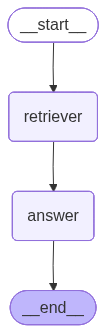

In [28]:
graph_builder.add_node("retriever", retriever)
graph_builder.add_node("answer", answer)

graph_builder.add_edge(START, "retriever")
graph_builder.add_edge("retriever", "answer")
graph_builder.add_edge("answer", END)

graph = graph_builder.compile()
graph

In [29]:
from langchain_core.messages import HumanMessage

In [30]:
response = graph.invoke(
    {
        "messages": [HumanMessage(content='치폴레는 대화형 AI를 활용했더니 어떻게 변했어?')]
    }
)

for msg in response['messages']:
    msg.pretty_print()

---------- RETRIEVER ----------
[CONTEXT]
 SPRi AI Brief
 2026년  3월호
22
채용의 부정적 영향과 개선 방안AI 
KEY Contents
고용주의 약 가 차 후보자에 를 활용하는 한편 구직자들도 이력서와 자기소개서 90% 1 AI , 
작성 면접 준비에 를 사용하면서 부정적 영향도 확대, AI
채용의 목표는 인간을 완전히 배제하는 것이 아니라 인간과 간 협력 체계의 구현으로AI AI , 
의미 파악과 동기 평가 윤리적 판단 등 인간 고유의 역할은 대체 불가능 , 
채용 시장에서 기업과 구직자의 활용의 보편화로 부정적 영향도 확대AI 
 세계경제포럼 의 년 월 발표에 따르면 고용주의 약 가 차 후보자 선별에 를(WEF) 2025 8 90% 1 AI  
활용하는 등 채용 분야에서 가 광범위하게 활용되는 추세AI
 일례로 레스토랑 체인 치폴레 는 대화형 를 활용해 채용 속도를 약 높였으며 아마존은 (Chipotle) AI 75% , 
자체 개발 알고리즘을 바탕으로 지원자의 전문 역량과 소프트 스킬 이력서를 기반으로 인재를 선별AI , 
 링크드인 몬스터 집리크루터 등의 주요 채용 플랫폼도 기반 (LinkedIn), (Monstoer), (ZipRecruiter) AI 
알고리즘을 광범위하게 활용해 기업에 적합한 후보자를 추천
 구직자들도 대부분 생성형 를 활용해 맞춤형 이력서와 자기소개서를 작성하고 면접 답변을 준비하며AI , 
알고리즘을 통해 몇 시간 만에 수백 개의 채용 공고에 지원하면서 채용 시장은 자동화 경쟁의 장으로 변모 
 그러나 가 채용 시장을 획기적으로 변화시킬 것이라는 기대와 달리 현재의 채용 시장은 여전히AI ,  
비효율적이며 채용의 영향으로 인한 부정적 영향도 다수 확인   AI 
 가 외형만 그럴듯하게 포장된 후보자를 대량 생산하는 데 일조하면서 기업들은 지원자뿐 아니라 자체 AI , 
선별 시스템 자체도 불신하게 되어 오히려 대면 면접과 추천 등 과거의 채용 방식으로 회귀
---

In [31]:
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [32]:
@tool
def retrive_ai_brief(query: str) -> str:
    '''
    Search and return information about AI technology and industry.
    '''
    docs = ensemble_retriever.invoke(query)
    if not docs:
        return "검색 결과가 없습니다"

    joined = "\n\n".join(
        f"[문서 {i+1}]\n{doc.page_content}"
        for i, doc in enumerate(docs)
    )
    return joined

In [33]:
tools = [retrive_ai_brief]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

In [34]:
def chatbot(state: MessagesState):
    response = llm_with_tools.invoke(state['messages'])
    return {"messages": [response]}

In [35]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """당신은 검색 결과를 바탕으로 질문에 답하는 AI 도우미입니다.
            반드시 한국어로 답변하세요.
            검색 결과에 없는 내용은 추측하지 말고 모른다고 답하세요.
            답변은 핵심 위주로 명확하게 작성하세요.

            아래는 검색된 문맥입니다:
            {context}
            """
        ), ("human", "{question}")
    ]
)

In [36]:
def answer(state: MessagesState):
    user_messages = [m for m in state['messages'] if m.type == 'human']
    question = user_messages[-1].content if user_messages else ""

    tool_messages = [m for m in state['messages'] if m.type == 'tool']
    context = "\n\n".join(m.content for m in tool_messages)

    chain = answer_prompt | llm
    response = chain.invoke(
        {
            "question": question,
            "context": context
        }
    )
    return {"messages": [response]}

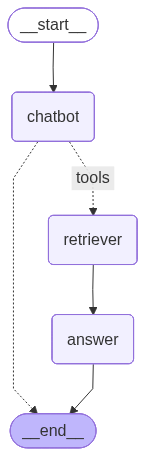

In [37]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("retriever", tool_node)
graph_builder.add_node("answer", answer)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "retriever",
        END: END
    }
)
graph_builder.add_edge("retriever", "answer")
graph_builder.add_edge("answer", END)
graph = graph_builder.compile()
graph

In [38]:
response = graph.invoke(
    {
        "messages": [
            HumanMessage(content='개방형 가중치 모델은 어떤 내용인가요? use tool')
        ]
    }
)

for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

개방형 가중치 모델은 어떤 내용인가요? use tool
================================== Ai Message ==================================
Tool Calls:
  retrive_ai_brief (call_ls5FbkS2r8VQBcyk0N5wLB09)
 Call ID: call_ls5FbkS2r8VQBcyk0N5wLB09
  Args:
    query: 개방형 가중치 모델(open-weight model)의 정의, 특징, 장단점, 오픈소스와의 차이 설명
================================= Tool Message =================================
Name: retrive_ai_brief

[문서 1]
 개방형 가중치 모델은 연구나 상업적 측면의 이점에도 불구하고 일단 출시되면 회수가 불가능하고 안전, 
장치를 쉽게 제거할 수 있으며 감시 환경을 벗어난 오용의 예방과 추적이 어렵다는 어려움을 내포
 관련 피해 발생 시 충격을 흡수하고 회복하는 사회적 복원력을 갖추기 위해서는 핵심 인프라 강화AI , 
생성물 탐지 도구 개발 새로운 위험에 대응할 수 있는 제도적 구축이 필요   AI , 
출처 | International AI Safety Report.org, International AI Safety Report 2026, 2026.2.3.
================================== Ai Message ==================================

검색 결과에 따르면, **개방형 가중치 모델**은 다음과 같은 특징과 한계를 가진 것으로 설명됩니다.

- 연구 및 상업적 측면에서 이점이 있음
- 하지만 **한 번 출시되면 회수가 불가능**함
- **안전 장치를 쉽게 제

# **4. 환각 여부를 평가하는 RAG**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcbH1BW%2FbtsQDGDjeF6%2FAAAAAAAAAAAAAAAAAAAAAD1nHS5umlxj-lmuCqR0YuDe0j5PgVVRieHu6sZt9609%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3DlNTTJGbYqeU9egEq5t6V4ieBUFI%253D'>